In [1]:
print("emo")

emo


In [23]:
import mne

edf_file = "Dataset/Signals/mesa-sleep-0002.edf"
raw = mne.io.read_raw_edf(edf_file, preload=False)

print("Channel names in EDF file:")
print(raw.ch_names)

Extracting EDF parameters from Dataset/Signals/mesa-sleep-0002.edf...
Setting channel info structure...
Creating raw.info structure...
Channel names in EDF file:
['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']


Extracting EDF parameters from Dataset/Signals/mesa-sleep-0001.edf...
Setting channel info structure...
Creating raw.info structure...


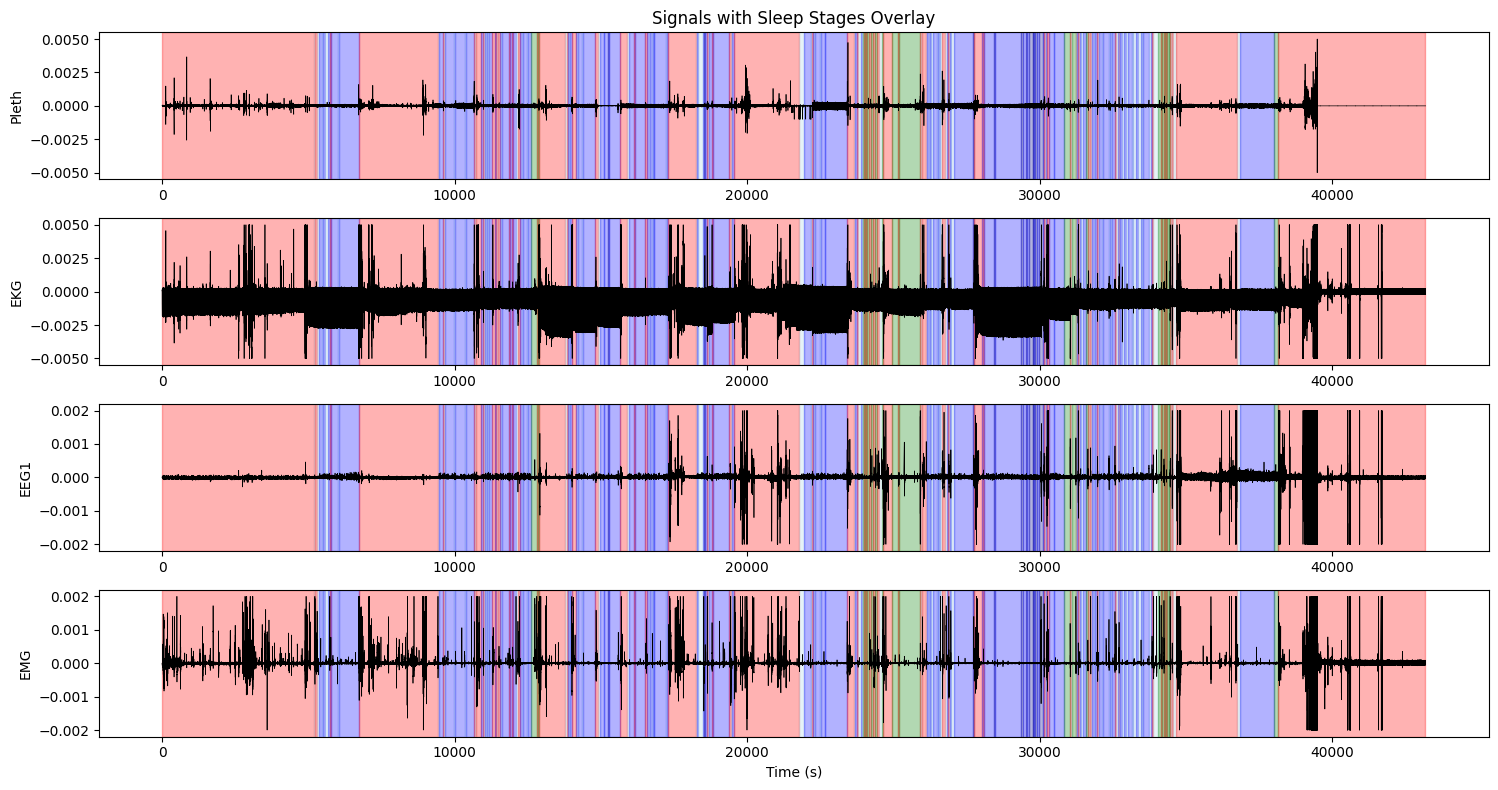

In [ ]:
import mne
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np


edf_file = "Dataset/Signals/mesa-sleep-0001.edf"
xml_file = "Dataset/Annotations/mesa-sleep-0001-nsrr.xml"


channels_to_plot = ['Pleth', 'EKG', 'EEG1', 'EMG']


tree = ET.parse(xml_file)
root = tree.getroot()
events = [e for e in root.findall(".//ScoredEvent") if e.find("EventType").text == "Stages|Stages"]


colors = {"Wake|0":"red", "Stage 1 sleep|1":"lightblue", "Stage 2 sleep|2":"blue",
          "Stage 3 sleep|3":"darkblue", "REM sleep|5":"green"}


chunk_duration = 300  
raw = mne.io.read_raw_edf(edf_file, preload=False)
sfreq = raw.info['sfreq']
total_time = int(raw.n_times / sfreq)
num_chunks = total_time // chunk_duration + 1

plt.figure(figsize=(15, len(channels_to_plot)*2))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(len(channels_to_plot), 1, i+1)
    
    for c in range(num_chunks):
        start_s = c * chunk_duration
        stop_s = min((c+1) * chunk_duration, total_time - 1/raw.info['sfreq'])
        raw_chunk = raw.copy().crop(tmin=start_s, tmax=stop_s)
        data = raw_chunk.get_data(picks=ch)[0]
        times = np.arange(len(data)) / sfreq + start_s
        
 
        ax.plot(times, data, color='black', linewidth=0.5)
        
   
    for e in events:
        start = float(e.find("Start").text)
        duration = float(e.find("Duration").text)
        stage = e.find("EventConcept").text
        color = colors.get(stage, "gray")
        
        ax.axvspan(start, start+duration, color=color, alpha=0.3)

    ax.set_ylabel(ch)
    if i == 0:
        ax.set_title("Signals with Sleep Stages Overlay")
    if i == len(channels_to_plot)-1:
        ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [ ]:
data split

In [ ]:
import os
import shutil
import numpy as np

edf_dir = "Dataset/Signals"
xml_dir = "Dataset/Annotations"
files = [f.replace(".edf","") for f in os.listdir(edf_dir) if f.endswith(".edf")]
files.sort() 

In [ ]:
np.random.seed(42) 
np.random.shuffle(files)

n = len(files)
train_end = int(n*0.7)
val_end = int(n*0.85)

train_files = files[:train_end]
val_files = files[train_end:val_end]
test_files = files[val_end:]

In [ ]:

for split in ["train","val","test"]:
    os.makedirs(f"Dataset/{split}/Signals", exist_ok=True)
    os.makedirs(f"Dataset/{split}/Annotations", exist_ok=True)


for f in train_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/train/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/train/Annotations/")

for f in val_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/val/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/val/Annotations/")

for f in test_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/test/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/test/Annotations/")